### Loading Packages & Configs

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from loader import load_data, get_batch
from tokenizer import Tokenizer
from train import Trainer
from dataclasses import dataclass
from plot_metrics import plot_metrics_history, plot_history
%load_ext autoreload
%autoreload 2

In [2]:
@dataclass
class Config:
    batch_size: int = 4
    vocab_size: int = None
    seq_len: int = 8
    n_layer: int = 4
    max_iters: int = 5000
    eval_interval: int = 500
    learning_rate: float = 3e-4
    device: str = 'mps' if torch.mps.is_available() else 'cpu'
    eval_iters: int = 200
    n_embd: int = 32
    n_head: int = 4
    data_split: float = 0.9

### Loading Data

In [3]:
text = load_data(filename="data/sample-TinyStories.txt")

Number of stories: 73
Length of text: 57107 characters


### Building Tokenizer & Train, Val dataset

In [4]:
tokenizer = Tokenizer(text)

In [5]:
print(f"Vocabulary size: {tokenizer.vocab_size}")

Vocabulary size: 61


In [6]:
config = Config(vocab_size=tokenizer.vocab_size)

In [7]:
data = tokenizer.encode(text)
data = torch.tensor(data, dtype=torch.long)

In [8]:
train_data = data[:int(config.data_split*len(data))]
val_data = data[int(config.data_split*len(data)):]
print(f"Train data length: {len(train_data)}")

Train data length: 51396


### GPT Architecture

In [39]:
from MultiHeadAttention import MultiHeadAttention
from FeedForward import FeedForward

In [ ]:
class BasicGPT(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.config = config
        self.token_embeddings = nn.Embedding(config.vocab_size,config.n_embd)
        self.pos_embeddings = nn.Embedding(config.seq_len,config.n_embd)
        self.muti_head = MultiHeadAttention(config)
        self.ffwd = FeedForward(config)
        self.lm_head = nn.Linear(config.n_embd,config.vocab_size)

    def forward(self,idx,target=None):
        B,T = idx.shape
        token_embed = self.token_embeddings(idx)
        pos_embed = self.pos_embeddings(torch.arange(T,device=config.device))
        x = token_embed + pos_embed
        x = self.muti_head(x)
        x = self.ffwd(x)
        logits = self.lm_head(x)
        if target is not None:
            batch,seq_len,vocab_size = logits.shape 
            logits = logits.view(batch*seq_len,vocab_size)
            target = target.view(batch*seq_len,)
            loss = F.cross_entropy(logits,target)
        else:
            loss = None

        return logits, loss
    
    def generate(self,idx,max_token_len):
        for _ in range(max_token_len):
            idx_seq_len = idx[:,-config.seq_len:]
            logits, _ = self(idx_seq_len)
            logits = logits[:,-1,:]
            probs = F.softmax(logits,dim=-1)
            next_tokens = torch.multinomial(probs,num_samples=1)
            idx = torch.concat([idx,next_tokens],dim=-1)     
        return idx 


### Training Model

In [30]:
model = BasicGPT(config)
model = model.to(config.device)

In [31]:
parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {parameters} | Number of trainable parameters: {parameters/1e6:.2f}M")

Parameters: 8317 | Number of trainable parameters: 0.01M


In [32]:
trainer = Trainer(model, train_data, val_data, config)

trainer.set_experiment("pos-embed + self-atten")  
trainer.train()

trainer.save_history("logs/experiment_history.json")
trainer.save_metrics('logs/metrics.json')

step    500 | train loss 2.9922 | val loss 2.9551 |    5.78 ms/step |      5543 tok/s 
step   1000 | train loss 2.8483 | val loss 2.8112 |    5.60 ms/step |      5718 tok/s 
step   1500 | train loss 2.7319 | val loss 2.7835 |    5.38 ms/step |      5952 tok/s 
step   2000 | train loss 2.6494 | val loss 2.6803 |    5.34 ms/step |      5990 tok/s 
step   2500 | train loss 2.5889 | val loss 2.6605 |    5.37 ms/step |      5957 tok/s 
step   3000 | train loss 2.5779 | val loss 2.6112 |    5.37 ms/step |      5960 tok/s 
step   3500 | train loss 2.5238 | val loss 2.5588 |    5.37 ms/step |      5961 tok/s 
step   4000 | train loss 2.5380 | val loss 2.5388 |    5.51 ms/step |      5804 tok/s 
step   4500 | train loss 2.4706 | val loss 2.5001 |    5.61 ms/step |      5706 tok/s 


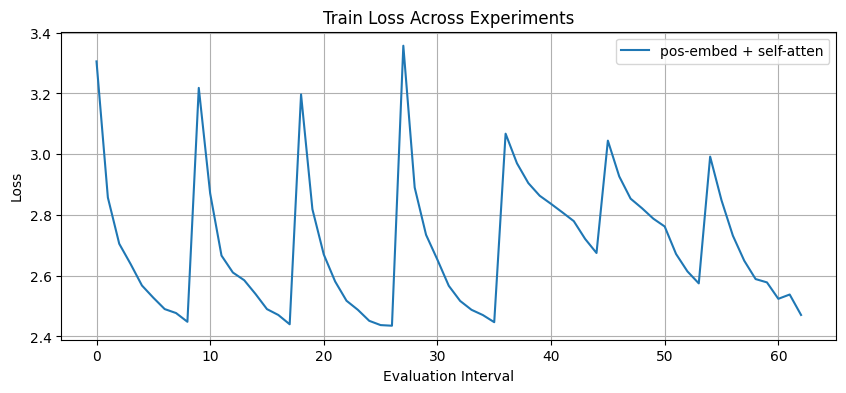

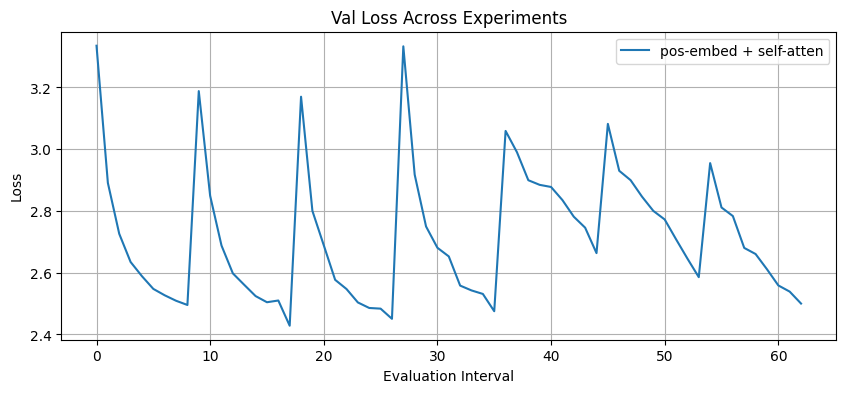

In [33]:
plot_history('logs/experiment_history.json','train')
plot_history('logs/experiment_history.json','val')

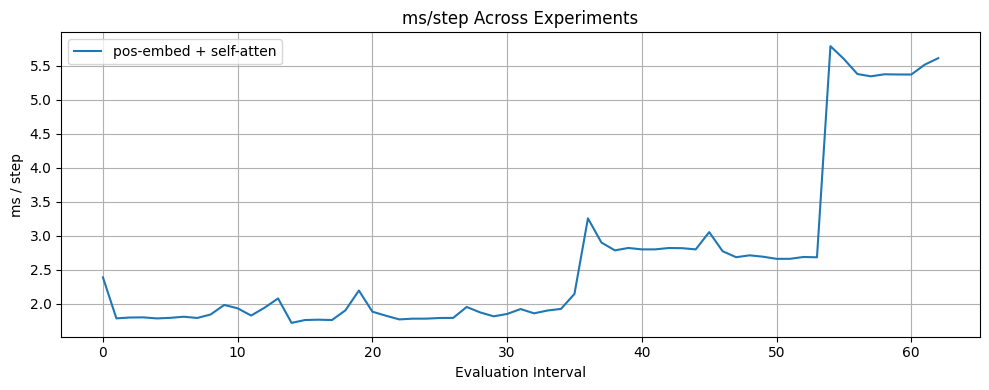

In [34]:

plot_metrics_history('logs/metrics.json', metric='ms_per_step')

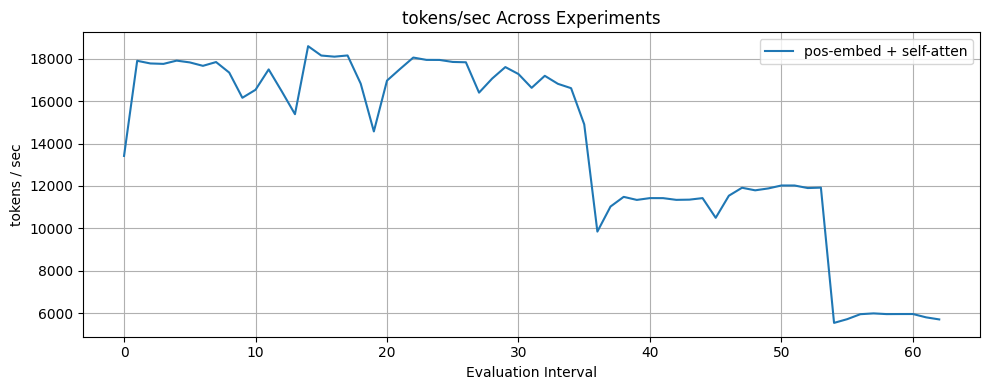

In [35]:
plot_metrics_history('logs/metrics.json', metric='tok_per_sec')

In [36]:
context = torch.zeros((1,1),dtype=torch.long,device='mps')

In [37]:
tokens = model.generate(context,1000).tolist()

In [38]:
print(tokenizer.decode(tokens[0]))



Ov rig Limhy te. "Od a  Rhe ves s Sf Tredir. OtHe ha adidnn t I e tumicadd. dowi Bev amy wase cas he pthiledam thed bfetheda yy. Eeche  st thend war hedt lbrenne rom thewakaned he that vg be Thim afe ts!lm pfe. won,. iledelbe pgel ad. f frs to Tububye btit'eh. he odd w!doh,,

Iiv. ITon?hedtofcr gef as. Woh fany She s!ey ame lelasit!u. Tam The olorir asri j e, Yarsos a ciutr!was uo bofeyor Tucan'eram mar,lIean. d Slde the it.o. “f The wher to
Tris pog he." Theyy wcichewud Tas ame and tink lip. It. 
On qhe wo ei, Be hhe icperit Thend St. Tocarit i ,uwhufanze fod fe pg tot imk s tha kit thete uThe cig "s we am flk ilato m I ay. whli breg. mh, 
H
Itakiv"
Odi egya prs s tis po Thee s J Hid, he aya. pgauH he tht!byoe ot s iso pWhey anen n phe tity "g ot pe heed wo l b gov.,

L"SI yile ot and tand s!cubesrenr id aser they Tso wid as mf and se withe anry say ther f anla wuu Sanl th, he"arlonyytis The bimBew B A, hen!fro!pm.en Taw wbes,y aton fed migigl Thegeg a am",. An'e w!intwaanss it tog 